### 📝 Importação dos dados



In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import numpy as np
import seaborn as sns
import folium
from folium.plugins import HeatMap
from IPython.display import display, HTML
from collections import defaultdict

url = "https://raw.githubusercontent.com/daniel-gramos/DesafioAluraStore/refs/heads/main/CSVs/loja_1.csv"
url2 = "https://raw.githubusercontent.com/daniel-gramos/DesafioAluraStore/refs/heads/main/CSVs/loja_2.csv"
url3 = "https://raw.githubusercontent.com/daniel-gramos/DesafioAluraStore/refs/heads/main/CSVs/loja_3.csv"
url4 = "https://raw.githubusercontent.com/daniel-gramos/DesafioAluraStore/refs/heads/main/CSVs/loja_4.csv"

loja1 = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

pd.set_option('display.width', 300)

#Exibe as 5 primeiras linhas de cada uma dos DataFrames das Lojas acima

lojas = [loja1, loja2, loja3, loja4]

for loja in lojas:
    print(loja.head())
    print('\n')


                 Produto Categoria do Produto    Preço      Frete Data da Compra        Vendedor Local da compra  Avaliação da compra Tipo de pagamento  Quantidade de parcelas    lat    lon
0     Assistente virtual          eletronicos   219.08   9.249790     16/01/2021     Pedro Gomes              SP                    4    cartao_credito                       8 -22.19 -48.79
1         Mesa de jantar               moveis   256.35  11.234305     18/05/2022  Beatriz Moraes              RJ                    1    cartao_credito                       4 -22.25 -42.66
2      Jogo de tabuleiro           brinquedos   279.51  21.262681     15/03/2021      João Souza              DF                    1    cartao_credito                       1 -15.83 -47.86
3            Micro-ondas     eletrodomesticos  1009.99  54.667344     03/05/2022      João Souza              RS                    4            boleto                       1 -30.17 -53.50
4  Cadeira de escritório               moveis   44

Primeiramente vamos verificar se alguma célula no DataFrame contém dados nulos (NaN).

Isso é importante pois caso tenha e não façamos a remoção dos mesmo ou a devida correção, eles podem impactar negativamente em nossas análises e consequentemente trazendo resultados menos precisos.

In [6]:
#Verificando se alguma coluna contém dados nulos (NaN)

# Obter contagem de valores nulos por loja
nulls_loja1 = loja1.isnull().sum().rename("Loja 1")
nulls_loja2 = loja2.isnull().sum().rename("Loja 2")
nulls_loja3 = loja3.isnull().sum().rename("Loja 3")
nulls_loja4 = loja4.isnull().sum().rename("Loja 4")

# Concatenar os resultados em um único DataFrame
nulls_comparativo = pd.concat([nulls_loja1, nulls_loja2, nulls_loja3, nulls_loja4], axis=1)

# Exibir as tabelas lado a lado
display(HTML("<h4>🔍 Valores Nulos por Coluna em Cada Loja</h4>"))
display(nulls_comparativo)


,Loja 1,Loja 2,Loja 3,Loja 4
Produto,0,0,0,0
Categoria do Produto,0,0,0,0
Preço,0,0,0,0
Frete,0,0,0,0
Data da Compra,0,0,0,0
Vendedor,0,0,0,0
Local da compra,0,0,0,0
Avaliação da compra,0,0,0,0
Tipo de pagamento,0,0,0,0
Quantidade de parcelas,0,0,0,0


Após verificarmos que as colunas estão OK, sem valores nulos (NaN) podemos seguir com a análise com mais segurança.

#1. 🧾 Análise do faturamento
Aqui criei uma função simples, para demonstrar o seu uso e fazer o cálculo do faturamento das 4 lojas. Eu poderia ter feito somente a soma dos valores e printado os mesmos em sequência, mas imaginemos que fosse um caso onde tivéssemos 100 lojas diferentes? Fica totalmente inviável ficar duplicando código 1 a 1 para fazer o cálculo


In [7]:
def calcular_faturamento():
  for i in range(len(lojas)):
    faturamento = lojas[i].Preço.sum()
    print("O faturamento da Loja%s foi de R$%.2f" % (i + 1, faturamento))

calcular_faturamento()

O faturamento da Loja1 foi de R$1534509.12
O faturamento da Loja2 foi de R$1488459.06
O faturamento da Loja3 foi de R$1464025.03
O faturamento da Loja4 foi de R$1384497.58


Em seguida um levantamento mais detalhado, trazendo o faturamento anual consilidado para cada loja. Foi utilizado a função reduce da biblioteca functools para mesclar os DataFrames e gerar uma melhor visualização.

In [8]:
lojas = [loja1, loja2, loja3, loja4]

# Converter a coluna 'Data da Compra' para datetime
for loja in lojas:
    loja['Data da Compra'] = pd.to_datetime(loja['Data da Compra'], format='%d/%m/%Y') # Especificando o formato da data

# Criar lista para armazenar os DataFrames de faturamento anual
faturamentos = []

# Calcular faturamento por ano para cada loja
for i, loja in enumerate(lojas, start=1):
    loja['Ano'] = loja['Data da Compra'].dt.year
    faturamento_anual = loja.groupby('Ano')['Preço'].sum().reset_index()
    faturamento_anual.columns = ['Ano', f'Loja {i}']
    faturamentos.append(faturamento_anual)

# Mesclar todos os DataFrames de faturamento pelo ano
from functools import reduce

faturamento_total = reduce(lambda left, right: pd.merge(left, right, on='Ano', how='outer'), faturamentos)

# Ordenar os anos e exibir resultado
faturamento_total = faturamento_total.sort_values('Ano').reset_index(drop=True)
print("\nFaturamento Anual Consolidado por Loja:\n")
display(faturamento_total)



Faturamento Anual Consolidado por Loja:



,Ano,Loja 1,Loja 2,Loja 3,Loja 4
0,2020,491911.51,427288.25,428943.09,441129.52
1,2021,482829.91,468288.89,483938.91,463763.27
2,2022,422086.24,477635.56,467250.70,402961.23
3,2023,137681.46,115246.36,83892.33,76643.56


E aqui gerei o primeiro gráfico de barras com o Faturamento Total de cada loja para começar a análise das informações e encontrar a melhor opção para o cliente Sr. João.

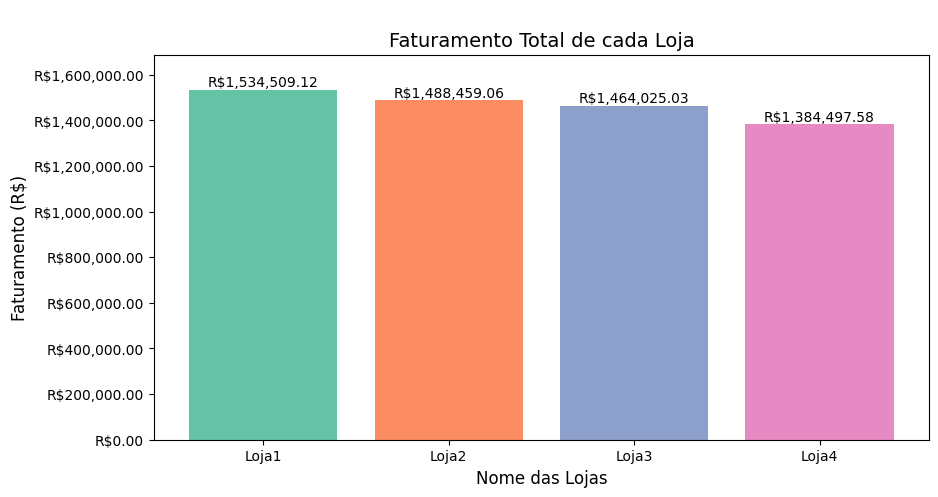

In [9]:
#Função para plotar gráfico de faturamento

def gerar_grafico_faturamento_total():
  nome_loja = []
  total_faturado = []

  for i in range(len(lojas)):
    nome_loja.append('Loja%s' % (i + 1))
    faturamento = lojas[i].Preço.sum()
    total_faturado.append(faturamento)

  plt.figure(figsize=(10, 5))
  bar_container = plt.bar(nome_loja, total_faturado, color=plt.cm.Set2.colors)
  plt.margins(x=0.05,y=0.1)

  plt.bar_label(bar_container, fmt='R${:,.2f}')

  plt.title('\nFaturamento Total de cada Loja', fontsize=14)
  plt.xlabel('Nome das Lojas', fontsize=12)
  plt.ylabel('Faturamento (R$)', fontsize=12)

  # Formata o eixo Y para exibir valores com R$
  formatter = mticker.StrMethodFormatter('R${x:,.2f}')
  plt.gca().yaxis.set_major_formatter(formatter)

  #plt.xticks(rotation=0)
  #plt.tight_layout()
  #plt.savefig('faturamento_total_das_loja.png', dpi=300, bbox_inches='tight')

  plt.show()

gerar_grafico_faturamento_total()

Aqui um gráfico de linhas, utilizando a biblioteca Seaborn e mostrando o faturamento de cada loja ao longo dos 4 anos. Percebam a queda acentuada que todas as lojas tiveram após o ano de 2022, com destaque especial para a Loja 4 a qual teve uma queda mais acentuada do que as demais.

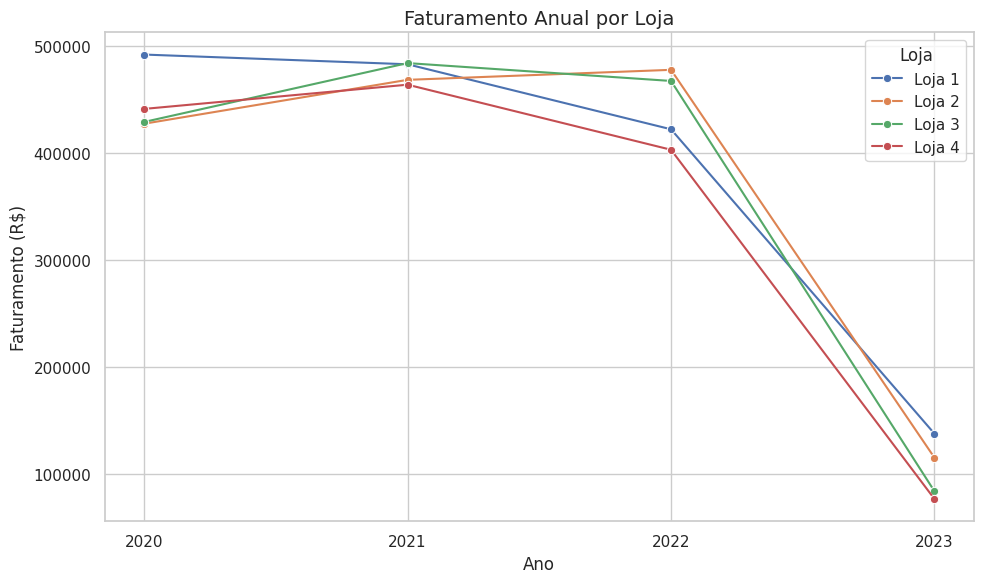

In [10]:
# Configurações de estilo
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# Converter o DataFrame para formato "longo" para facilitar o uso com seaborn
faturamento_melted = faturamento_total.melt(id_vars='Ano', var_name='Loja', value_name='Faturamento')

# Plotando gráfico de linhas
sns.lineplot(data=faturamento_melted, x='Ano', y='Faturamento', hue='Loja', marker='o')

# Títulos e rótulos
plt.title("Faturamento Anual por Loja", fontsize=14)
plt.xlabel("Ano")
plt.ylabel("Faturamento (R$)")
plt.legend(title='Loja')
plt.xticks(faturamento_total['Ano'].unique())  # Garante que os anos do eixo X sejam corretos
plt.tight_layout()
plt.show()


# 2. 📦 Vendas por Categoria
Aqui comecei a análise da quantidade de vendas por cada categoria e em cada loja separadamente.

In [11]:
print("Quantidade de produtos vendidos por categoria:\n")
for i, loja in enumerate(lojas, start=1):
    print("-------------------------------------------------")
    print(f"Loja {i}")
    print("Nome da Categoria:".ljust(40) + "Quantidade de Vendas:")

    categorias = loja['Categoria do Produto'].value_counts().reset_index()
    categorias.columns = ['Categoria do Produto', 'Quantidade de Vendas']

    for idx, row in categorias.iterrows():
        categoria_nome = row['Categoria do Produto'].title()
        quantidade = row['Quantidade de Vendas']
        print(categoria_nome.ljust(40) + str(quantidade))

    print("-------------------------------------------------\n")
    print('\n')

todas_lojas = pd.concat(lojas)
print("Quantidade de produtos vendidos por categoria em todas as lojas: \n")
print("Nome da Categoria:".ljust(40) + "Quantidade de Vendas:")
categorias_total = todas_lojas['Categoria do Produto'].value_counts()

for categoria, quantidade in categorias_total.items():
    print(f"{categoria.title().ljust(40)}{quantidade}")

print("-------------------------------------------------")

Quantidade de produtos vendidos por categoria:

-------------------------------------------------
Loja 1
Nome da Categoria:                      Quantidade de Vendas:
Moveis                                  465
Eletronicos                             448
Brinquedos                              324
Eletrodomesticos                        312
Esporte E Lazer                         284
Instrumentos Musicais                   182
Livros                                  173
Utilidades Domesticas                   171
-------------------------------------------------



-------------------------------------------------
Loja 2
Nome da Categoria:                      Quantidade de Vendas:
Moveis                                  442
Eletronicos                             422
Brinquedos                              313
Eletrodomesticos                        305
Esporte E Lazer                         275
Instrumentos Musicais                   224
Livros                                  197
U

Após a coleta dos dados, plotei 4 gráficos no formato pizza para representar a quantidade de vendas de cada categoria e facilitar a visualização

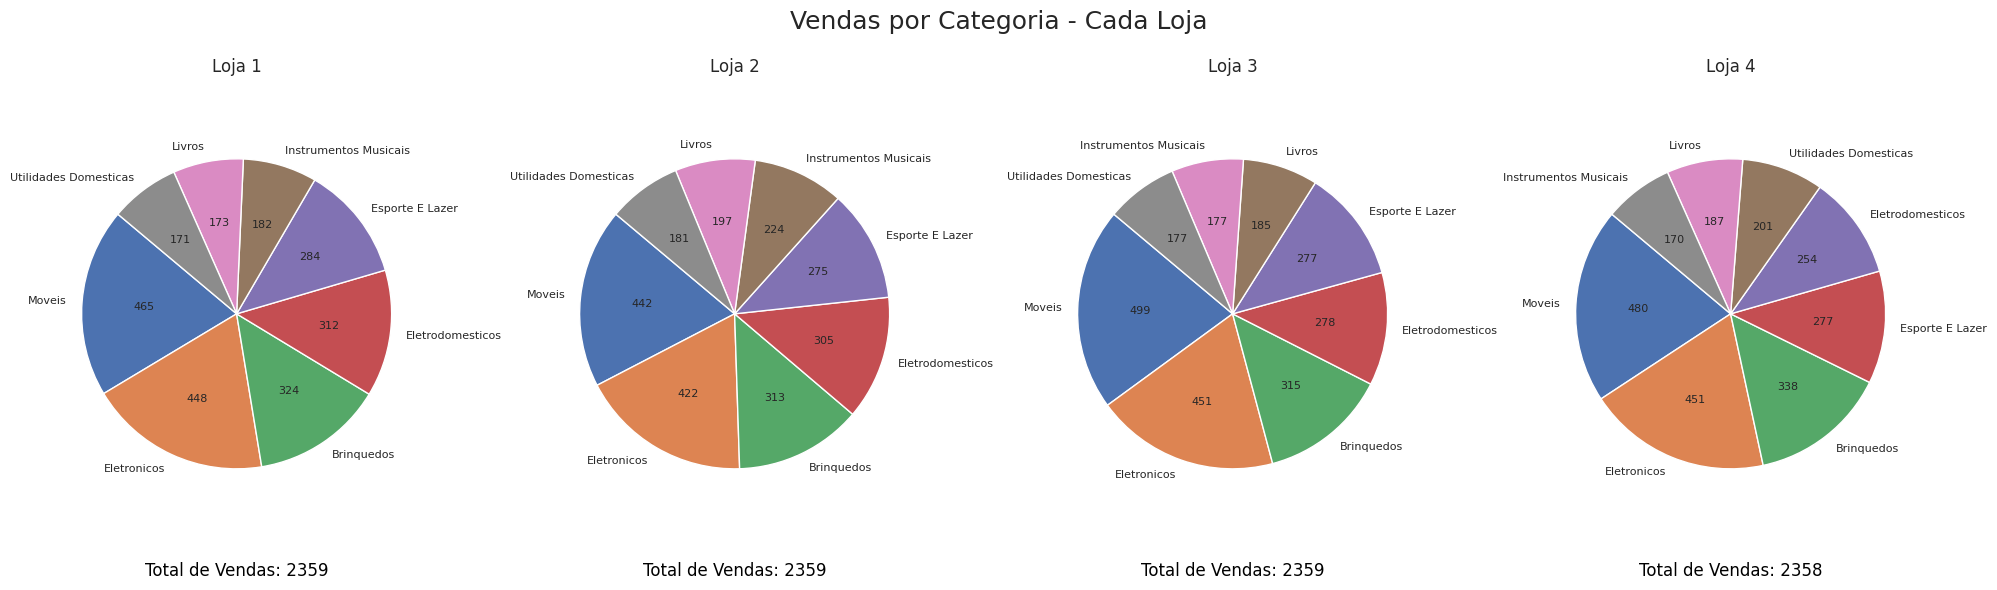

In [12]:
# Função para formatar o valor (quantidade ao invés de porcentagem)
def formata_valor(pct, valores):
    total = sum(valores)
    valor = int(round(pct * total / 100.0))
    return f'{valor}'

# Criar os subplots lado a lado
fig, axs = plt.subplots(1, 4, figsize=(20,6))  # 1 linha, 4 colunas

for i, (loja, ax) in enumerate(zip(lojas, axs), start=1):
    categorias = loja['Categoria do Produto'].value_counts()

    # Gerar o gráfico de pizza
    ax.pie(
        categorias,
        labels=[cat.title() for cat in categorias.index],
        autopct=lambda pct: formata_valor(pct, categorias),
        startangle=140,
        textprops={'fontsize': 8}
    )

    # Calcular o total de vendas para a loja
    total_vendas = categorias.sum()

    # Adicionar título e total de vendas abaixo
    ax.set_title(f'Loja {i}', fontsize=12)
    ax.axis('equal')  # Pizza certinha

    # Exibir total de vendas abaixo do gráfico
    ax.annotate(f'Total de Vendas: {total_vendas}',
                xy=(0.5, -0.05), xycoords='axes fraction',
                ha='center', va='center', fontsize=12, color='black')

plt.suptitle('Vendas por Categoria - Cada Loja', fontsize=18)
plt.tight_layout()
plt.show()

E em sequência plotei um gráfico geral com o total de vendas por Categoria de todas as lojas

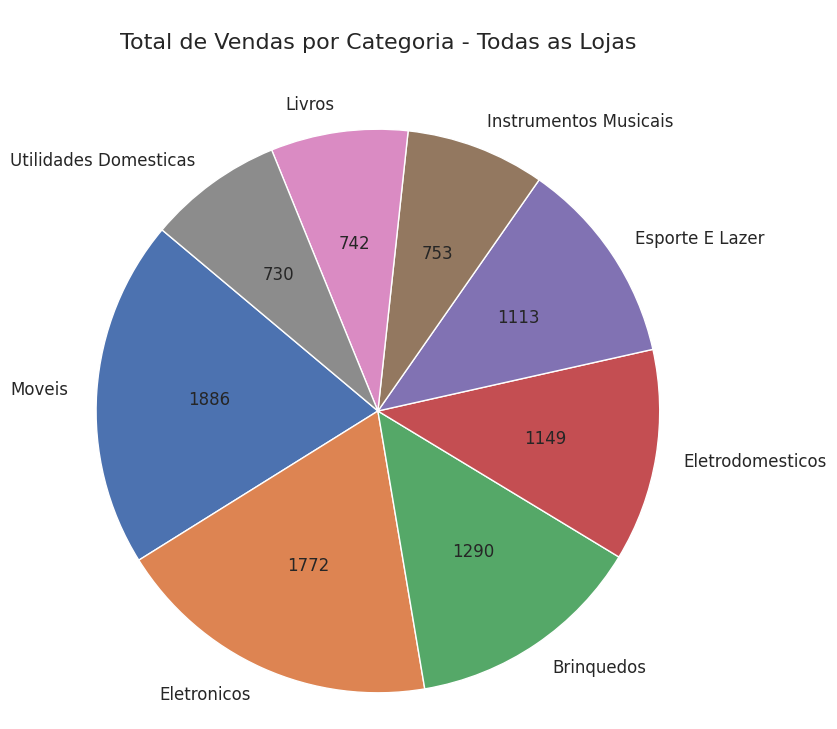

In [13]:
def formata_valor(pct, valores):
    total = sum(valores)
    valor = int(round(pct * total / 100.0))
    return f'{valor}'

# Juntando as lojas
todas_lojas = pd.concat(lojas)

categorias_total = todas_lojas['Categoria do Produto'].value_counts()

# Gráfico geral
plt.figure(figsize=(8,8))
plt.pie(
    categorias_total,
    labels=[cat.title() for cat in categorias_total.index],
    autopct=lambda pct: formata_valor(pct, categorias_total),
    startangle=140,
    textprops={'fontsize': 12}
)

plt.title('\nTotal de Vendas por Categoria - Todas as Lojas\n\n', fontsize=16)
plt.axis('equal')
plt.show()

Buscando mais informações, gerei outros 4 gráficos separados as categorias e as lojas individualmente, só que dessa vez trazendo o valor total de vendas em cada categoria. Com isso, é possível identificar quais categorias tem maior potencial de retorno financeiro.

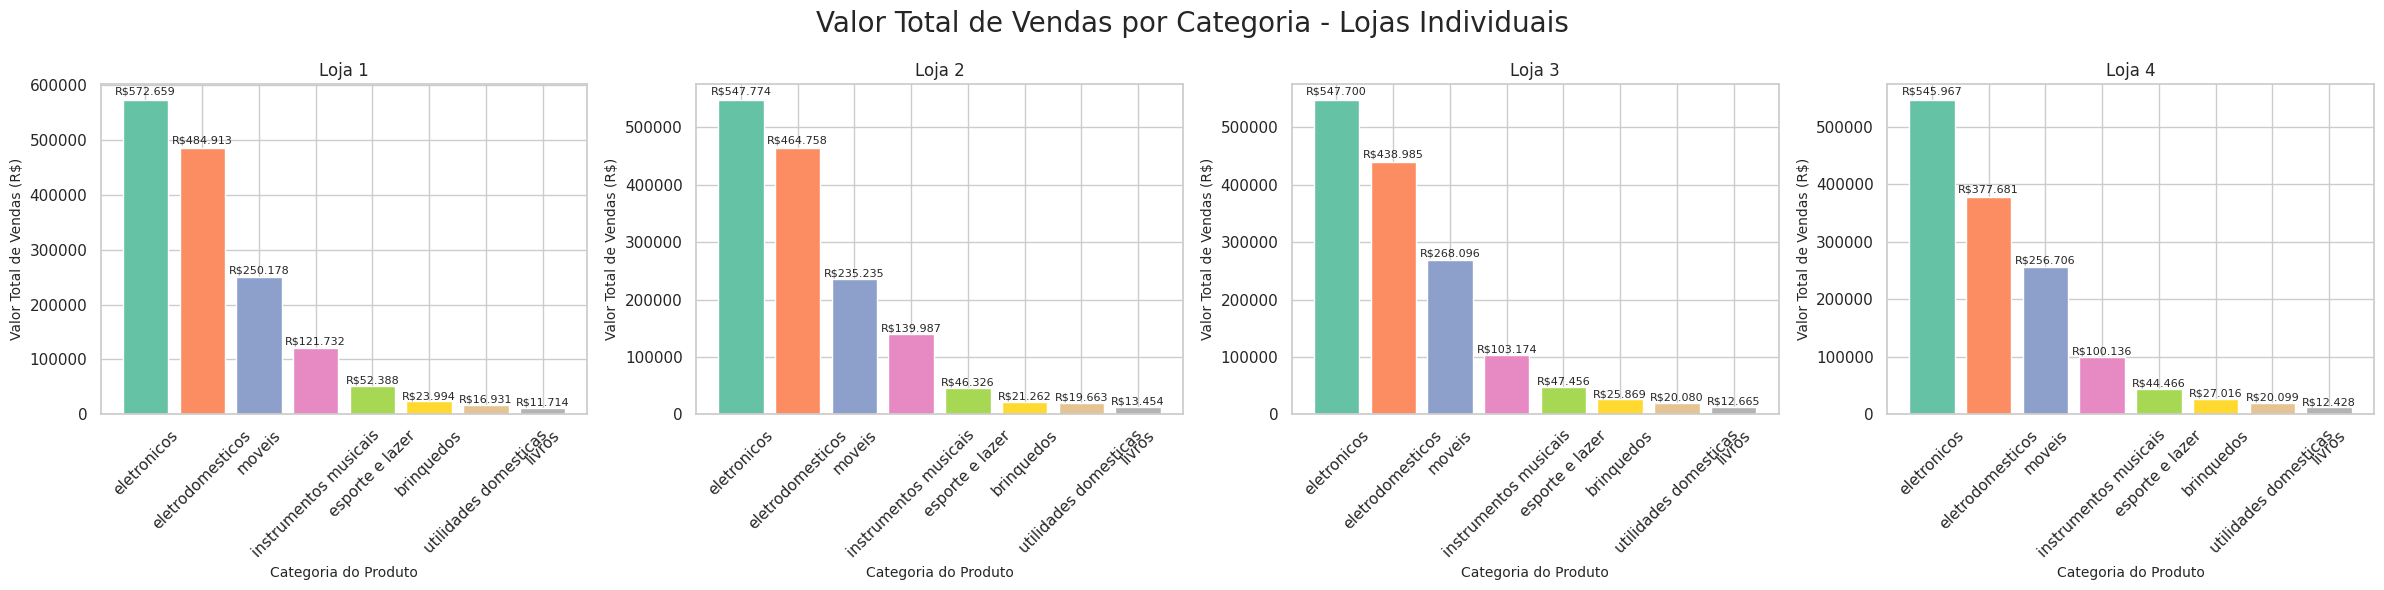

In [14]:
# Escolhendo uma paleta de cores
cores = plt.cm.Set2(np.linspace(0, 1, 8))  # 8 cores diferentes do Set2

# Criar subplots para as lojas
fig, axs = plt.subplots(1, 4, figsize=(24,6))  # 1 linha, 4 colunas

for i, (loja, ax) in enumerate(zip(lojas, axs), start=1):
    # Agrupar por categoria e somar os valores
    categorias_valores = loja.groupby('Categoria do Produto')['Preço'].sum().sort_values(ascending=False)

    # Gráfico de barras com cores variadas
    ax.bar(
        categorias_valores.index,
        categorias_valores.values,
        color=cores[:len(categorias_valores)]
    )

    # Título e ajustes
    ax.set_title(f'Loja {i}', fontsize=12)
    ax.set_xlabel('Categoria do Produto', fontsize=10)
    ax.set_ylabel('Valor Total de Vendas (R$)', fontsize=10)
    ax.tick_params(axis='x', rotation=45)

    # Mostrar o valor acima de cada barra
    for idx, valor in enumerate(categorias_valores.values):
        ax.text(idx, valor + (valor * 0.01), f'R${valor:,.0f}'.replace(",", "."), ha='center', va='bottom', fontsize=8)

plt.suptitle('Valor Total de Vendas por Categoria - Lojas Individuais', fontsize=20)
plt.tight_layout()
plt.show()


E por fim, plotei um gráfico Geral com o Total de Vendas por categoria de Todas as Lojas

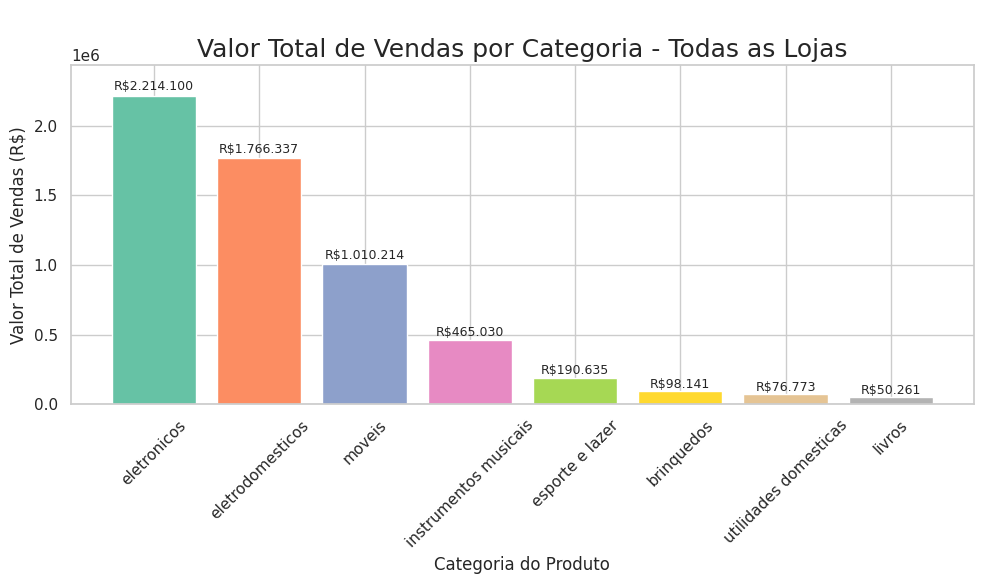

In [15]:
# Escolhendo uma paleta de cores
cores = plt.cm.Set2(np.linspace(0, 1, 8))  # 8 cores diferentes do Set2

# Concatenar todas as lojas
todas_lojas = pd.concat(lojas)

# Agrupar e somar os valores por categoria
categorias_valores_total = todas_lojas.groupby('Categoria do Produto')['Preço'].sum().sort_values(ascending=False)

# Gráfico de barras geral
plt.figure(figsize=(10,6))
plt.bar(
    categorias_valores_total.index,
    categorias_valores_total.values,
    color=cores[:len(categorias_valores_total)]
)

# Título e ajustes
plt.title('\nValor Total de Vendas por Categoria - Todas as Lojas', fontsize=18)
plt.xlabel('Categoria do Produto', fontsize=12)
plt.ylabel('Valor Total de Vendas (R$)', fontsize=12)
plt.margins(x = 0.05, y = 0.1)
plt.xticks(rotation=45)

# Mostrar o valor acima de cada barra
for idx, valor in enumerate(categorias_valores_total.values):
    plt.text(idx, valor + (valor * 0.01), f'R${valor:,.0f}'.replace(",", "."), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# 3. ⭐ Média de Avaliação das Lojas

Aqui fiz um levantamento de todas as avaliações dos clientes e com isso obtive uma média para cada loja.

In [16]:
# Lista para armazenar as médias
medias_avaliacao = []

for i, loja in enumerate(lojas, start=1):
    media = loja['Avaliação da compra'].mean()
    medias_avaliacao.append((f'Loja {i}', media))
    print(f'Média de Avaliação da Loja {i}: {media:.2f}')


Média de Avaliação da Loja 1: 3.98
Média de Avaliação da Loja 2: 4.04
Média de Avaliação da Loja 3: 4.05
Média de Avaliação da Loja 4: 4.00


Com as médias em mãos, plotei um gráfico de barras para melhor visualização das mesmas.

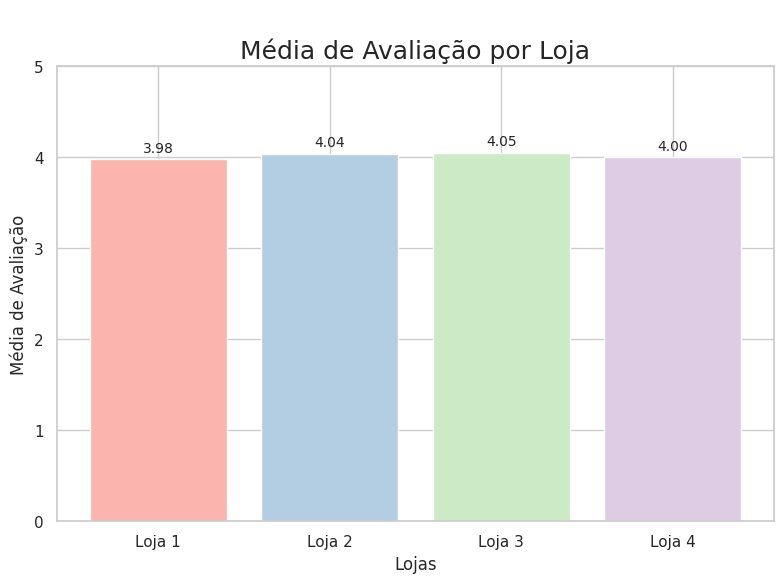

In [17]:
# Separando as lojas e as médias
lojas_nomes = [nome for nome, _ in medias_avaliacao]
avaliacoes_medias = [media for _, media in medias_avaliacao]

# Gráfico
plt.figure(figsize=(8,6))
bars = plt.bar(lojas_nomes, avaliacoes_medias, color=plt.cm.Pastel1(range(len(lojas_nomes))))

# Títulos e ajustes
plt.title('\nMédia de Avaliação por Loja', fontsize=18)
plt.xlabel('Lojas', fontsize=12)
plt.ylabel('Média de Avaliação', fontsize=12)
plt.ylim(0, 5)  # Avaliações geralmente vão de 0 a 5
#plt.grid(axis='y', linestyle='--', alpha=0.7)

# Colocar o valor em cima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.05, f'{height:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# 4. 🛒 Produtos Mais e Menos Vendidos
Aqui fiz um levantamento dos produtos mais vendido e menos vendidos. Utilizei o método value_counts() para calcular quantas vezes cada produto aparece nos DataFrames e em seguida os métodos idxmax() para retornar o produto mais vendido, seguido do método max() para me trazer a maior quantidade de vendas desse produto. O mesmo foi feito para os menos vendidos, utilizando os métodos idxmin() e min(). Feito um append dos valores e na lista produtos_vendas e em seguida exibi os menos com a função print().
Em sequência fiz uma outra alternativa para exibição dos mesmos datos, dessa vez exibindo as informações utilizando diretamente os DataFrames.

In [18]:
# Para armazenar os resultados
produtos_vendas = []

for i, loja in enumerate(lojas, start=1):
    # Contar quantas vezes cada produto aparece
    contagem_produtos = loja['Produto'].value_counts()

    produto_mais_vendido = contagem_produtos.idxmax()
    quantidade_mais_vendido = contagem_produtos.max()

    produto_menos_vendido = contagem_produtos.idxmin()
    quantidade_menos_vendido = contagem_produtos.min()

    produtos_vendas.append({
        'Loja': f'Loja {i}',
        'Produto Mais Vendido': produto_mais_vendido,
        'Quantidade Mais Vendido': quantidade_mais_vendido,
        'Produto Menos Vendido': produto_menos_vendido,
        'Quantidade Menos Vendido': quantidade_menos_vendido
    })

    print(f"Loja {i}:")
    print(f"  Produto mais vendido: {produto_mais_vendido} ({quantidade_mais_vendido} vendas)")
    print(f"  Produto menos vendido: {produto_menos_vendido} ({quantidade_menos_vendido} vendas)\n")

produtos_vendas_geral = []

for i, loja in enumerate(lojas, start=1):
    # Contar quantas vezes cada produto aparece
    contagem_produtos = loja['Produto'].value_counts()

    produto_mais_vendido = contagem_produtos.idxmax()
    quantidade_mais_vendido = contagem_produtos.max()

    produto_menos_vendido = contagem_produtos.idxmin()
    quantidade_menos_vendido = contagem_produtos.min()

    produtos_vendas_geral.append({
        'Loja': f'Loja {i}',
        'Produto Mais Vendido': produto_mais_vendido,
        'Quantidade Mais Vendido': quantidade_mais_vendido,
        'Produto Menos Vendido': produto_menos_vendido,
        'Quantidade Menos Vendido': quantidade_menos_vendido
    })

# Criar DataFrame para visualizar os resultados
df_produtos_vendas = pd.DataFrame(produtos_vendas)

# Exibir o DataFrame
print(df_produtos_vendas)


Loja 1:
  Produto mais vendido: Micro-ondas (60 vendas)
  Produto menos vendido: Headset (33 vendas)

Loja 2:
  Produto mais vendido: Iniciando em programação (65 vendas)
  Produto menos vendido: Jogo de tabuleiro (32 vendas)

Loja 3:
  Produto mais vendido: Kit banquetas (57 vendas)
  Produto menos vendido: Blocos de montar (35 vendas)

Loja 4:
  Produto mais vendido: Cama box (62 vendas)
  Produto menos vendido: Guitarra (33 vendas)

     Loja      Produto Mais Vendido  Quantidade Mais Vendido Produto Menos Vendido  Quantidade Menos Vendido
0  Loja 1               Micro-ondas                       60               Headset                        33
1  Loja 2  Iniciando em programação                       65     Jogo de tabuleiro                        32
2  Loja 3             Kit banquetas                       57      Blocos de montar                        35
3  Loja 4                  Cama box                       62              Guitarra                        33


Após gerar os valores, plotei um gráfico de barras para cada uma das lojas, mostrando os TOP 5 produtos mais vendidos.

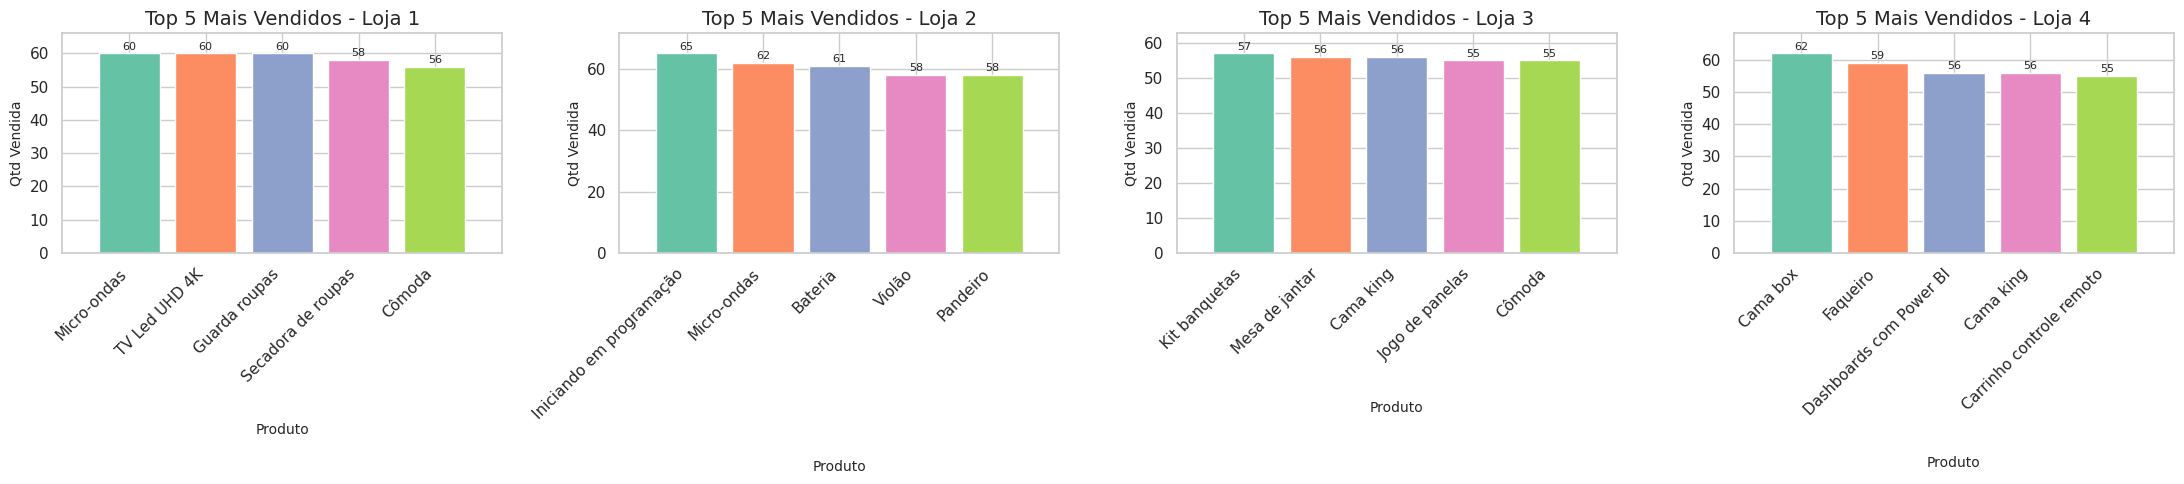

In [19]:
# Define a quantidade de lojas
num_lojas = len(lojas)

# Cria subplots (1 linha, várias colunas)
fig, axes = plt.subplots(1, num_lojas, figsize=(22,5))  # Aumentei o tamanho para caber tudo

for i, (loja, ax) in enumerate(zip(lojas, axes), start=1):
    top5 = loja['Produto'].value_counts().head(5)

    bars = ax.bar(top5.index, top5.values, color=plt.cm.Set2.colors)

    ax.set_title(f'Top 5 Mais Vendidos - Loja {i}', fontsize=14)
    ax.set_xlabel('\n\nProduto', fontsize=10)
    ax.set_ylabel('Qtd Vendida', fontsize=10)
    ax.set_xticks(range(len(top5.index)))
    ax.set_xticklabels(top5.index, rotation=45, ha='right')
    ax.margins(x = 0.1, y = 0.1)
    #ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Adicionando valores acima das barras
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, int(height), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

Aqui plotei um gráfico dos TOP 5 Produtos Mais Vendidos de Todas as Lojas

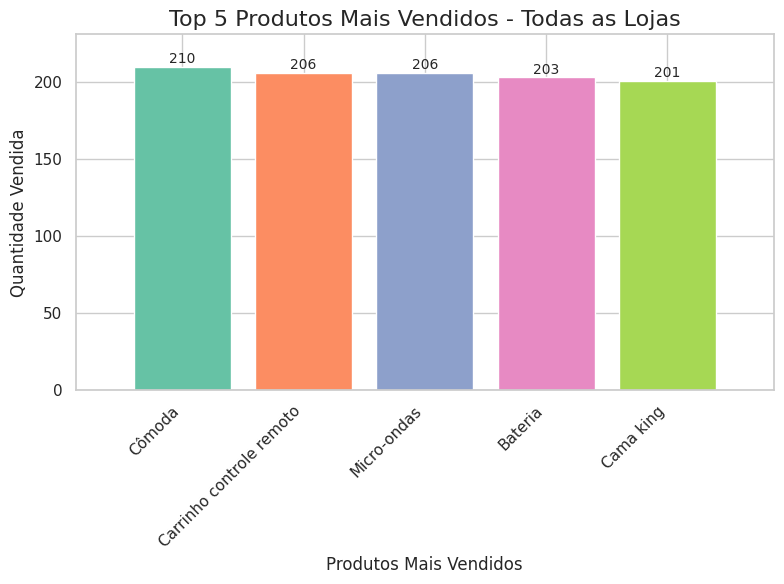

In [20]:
# Agora o gráfico geral das lojas (separado)
todas_lojas = pd.concat(lojas)
top5_geral = todas_lojas['Produto'].value_counts().head(5)

plt.figure(figsize=(8,6))
bars = plt.bar(top5_geral.index, top5_geral.values, color=plt.cm.Set2.colors)

plt.title('Top 5 Produtos Mais Vendidos - Todas as Lojas', fontsize=16)
plt.xlabel('Produtos Mais Vendidos', fontsize=12)
plt.ylabel('Quantidade Vendida', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.margins(x = 0.1, y = 0.1)
#plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionando valores acima das barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, int(height), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Aqui plotei um gráfico de barras para cada uma das lojas, mostrando os TOP 5 produtos Menos vendidos.

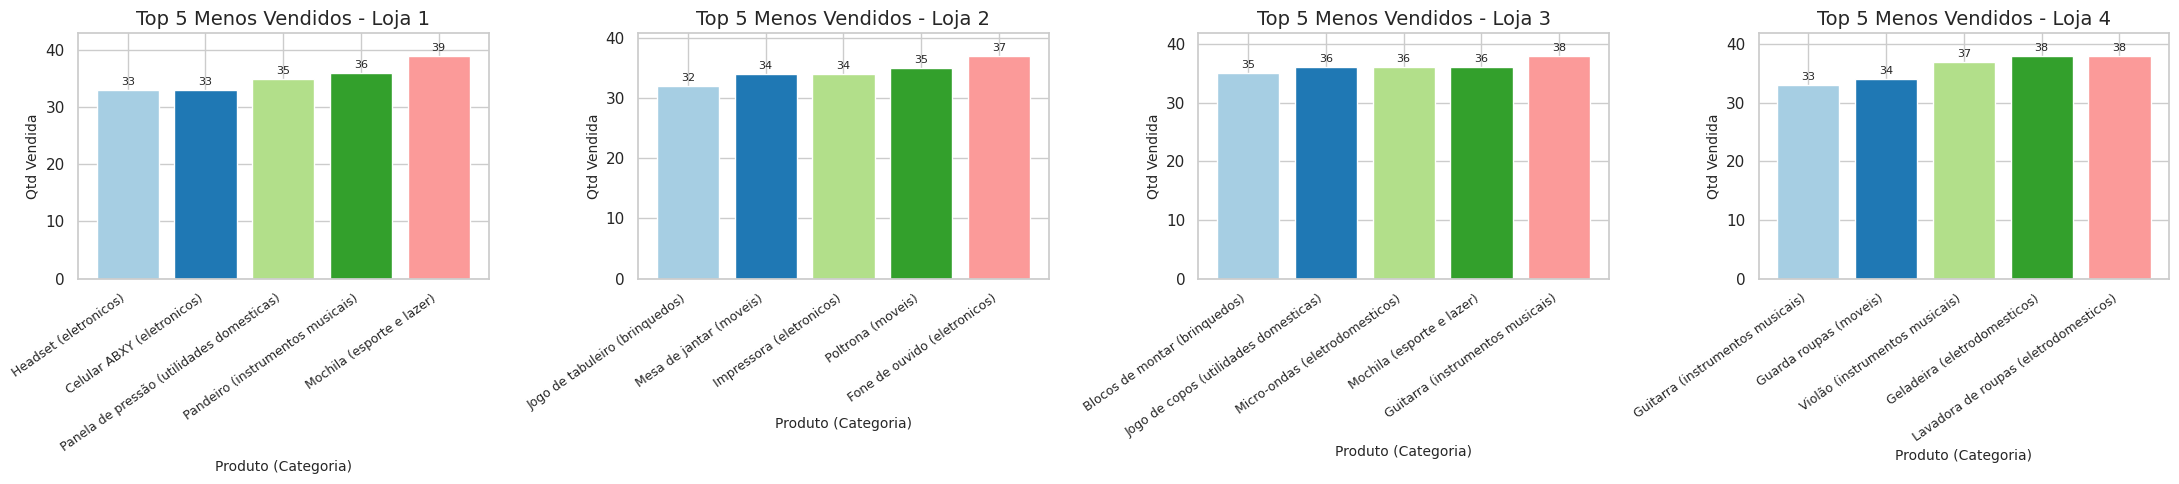

In [21]:
# Define a quantidade de lojas
num_lojas = len(lojas)

# Cria subplots (1 linha, várias colunas)
fig, axes = plt.subplots(1, num_lojas, figsize=(22,5))  # Layout horizontal

# Plotando os Top 5 Menos Vendidos por loja
for i, (loja, ax) in enumerate(zip(lojas, axes), start=1):
    # Contagem de produtos
    contagem_produtos = loja['Produto'].value_counts(ascending=True)
    top5_menos_vendidos = contagem_produtos.head(5)

    # Extrair os nomes dos produtos e buscar suas categorias
    produtos_top5 = top5_menos_vendidos.index.tolist()

    # Criar rótulos no formato: Produto (Categoria)
    produto_categoria_labels = []
    for produto in produtos_top5:
        categoria = loja.loc[loja['Produto'] == produto, 'Categoria do Produto'].iloc[0]
        produto_categoria_labels.append(f"{produto} ({categoria})")

    # Plotar
    bars = ax.bar(produto_categoria_labels, top5_menos_vendidos.values, color=plt.cm.Paired.colors)

    ax.set_title(f'Top 5 Menos Vendidos - Loja {i}', fontsize=14)
    ax.set_xlabel('Produto (Categoria)', fontsize=10)
    ax.set_ylabel('Qtd Vendida', fontsize=10)
    ax.set_xticks(range(len(produto_categoria_labels)))
    ax.set_xticklabels(produto_categoria_labels, rotation=35, ha='right', fontsize=9)
    ax.margins(x=0.05, y=0.1)

    # Adicionar valores acima das barras
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, int(height),
                ha='center', va='bottom', fontsize=8)

# Ajustar layout
plt.tight_layout()
plt.show()


Aqui plotei um gráfico dos TOP 5 Produtos Menos Vendidos de Todas as Lojas

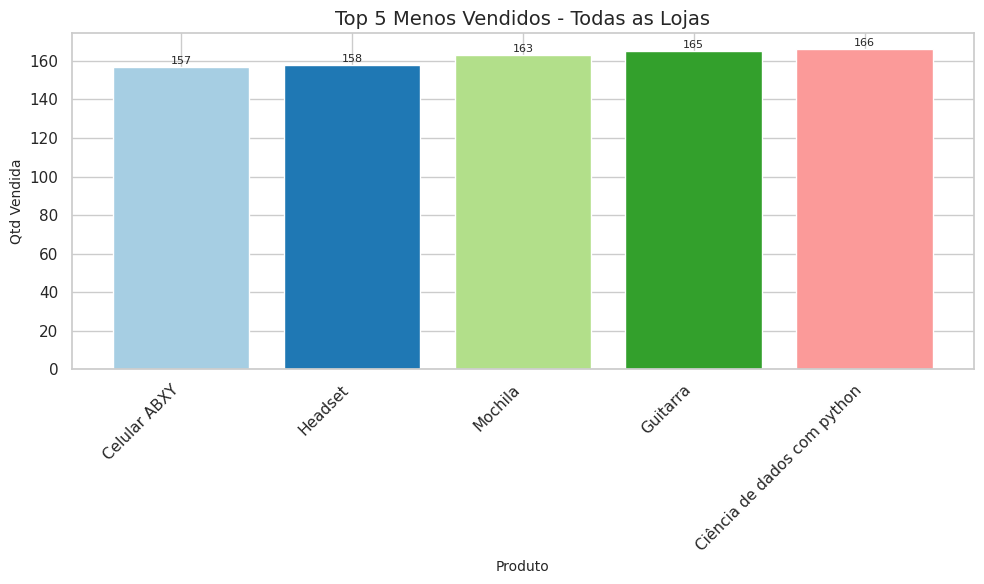

In [22]:
# Combina os dados das 4 lojas em um único DataFrame
todos_produtos = pd.concat(lojas)

# Contagem e ordenação para obter os 5 produtos menos vendidos
top5_menos_vendidos_geral = todos_produtos['Produto'].value_counts(ascending=True).head(5)

# Plotando o gráfico
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(top5_menos_vendidos_geral.index, top5_menos_vendidos_geral.values, color=plt.cm.Paired.colors)

ax.set_title('Top 5 Menos Vendidos - Todas as Lojas', fontsize=14)
ax.set_xlabel('Produto', fontsize=10)
ax.set_ylabel('Qtd Vendida', fontsize=10)
ax.set_xticks(range(len(top5_menos_vendidos_geral.index)))
ax.set_xticklabels(top5_menos_vendidos_geral.index, rotation=45, ha='right')
#ax.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionando valores acima das barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, int(height), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

Aqui plotei um outro gráfico dos TOP 5 Produtos Menos Vendidos de Todas as Lojas, apenas adicionando junto a categoria a qual o produto pertence para facilitar a identificação. Quandi li o Top 5 menos vendido acima, Ciência de dados com python fiquei em dúvida sobre qual categoria ele pertencia, um livro? video aula? curso? Então plotei o novo gráfico mostrando as categorias

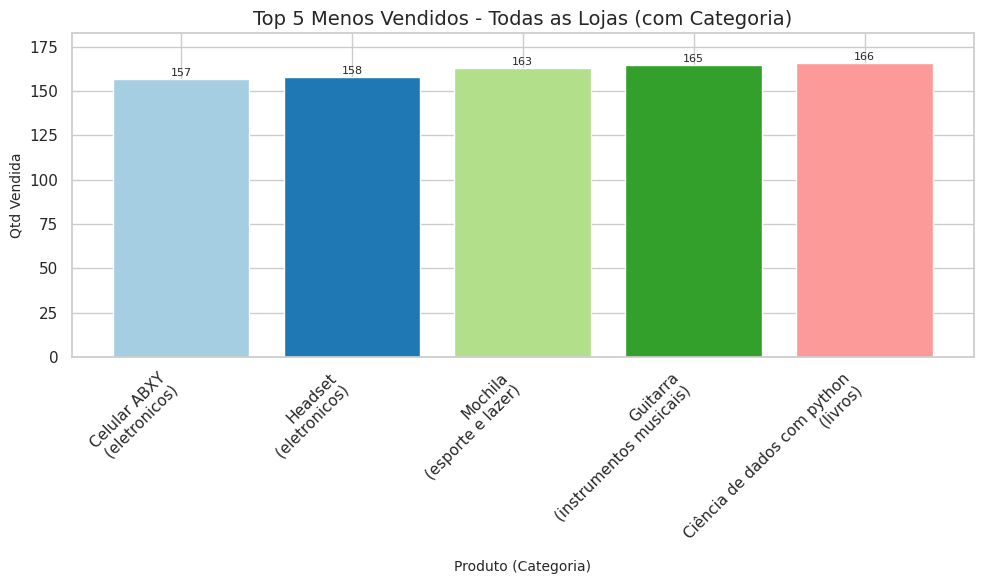

In [23]:
# Combina os dados das 4 lojas
todos_produtos = pd.concat(lojas)

# Cria uma coluna com Produto + Categoria
todos_produtos['Categoria do Produto'] = todos_produtos['Produto'] + '\n (' + todos_produtos['Categoria do Produto'] + ')'

# Conta e ordena os menos vendidos com base no novo campo
top5_menos_vendidos_geral_com_categorias = todos_produtos['Categoria do Produto'].value_counts(ascending=True).head(5)

# Plotando o gráfico
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(top5_menos_vendidos_geral_com_categorias.index, top5_menos_vendidos_geral_com_categorias.values, color=plt.cm.Paired.colors)

ax.set_title('Top 5 Menos Vendidos - Todas as Lojas (com Categoria)', fontsize=14)
ax.set_xlabel('Produto (Categoria)', fontsize=10)
ax.set_ylabel('Qtd Vendida', fontsize=10)
ax.set_xticks(range(len(top5_menos_vendidos_geral_com_categorias.index)))
ax.set_xticklabels(top5_menos_vendidos_geral_com_categorias.index, rotation=45, ha='right')
#ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.margins(x = 0.05, y = 0.1)

# Adiciona os valores acima das barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, int(height), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


# 5. 🚚 Frete Médio por Loja
Aqui fiz o cálculo médio dos fretes e os agrupei por Categoria de Produto. Fiz também um levantamento da % do valor do frete em relação ao valor do pedido, para verificar se haveria alguma divergência entre as categorias e lojas. Após o resultado, estavam tudo ok. Apenas uma pequena variação de uma loja para outra. Somente o frete total da Loja 4 ficou menor que os demais.

In [24]:
# Loop para processar cada loja individualmente
for idx, loja in enumerate(lojas, start=1):
    print(f"\n=== Loja {idx} ===")

    # Agrupamento e agregações
    resultado = loja.groupby('Categoria do Produto').agg(
        Quantidade_Produtos=('Frete', 'count'),
        Frete_Medio=('Frete', 'mean'),
        Preco_Medio=('Preço', 'mean'),
        Frete_Total=('Frete', 'sum')
    ).reset_index()

    # Cálculo da % do frete sobre o preço médio
    resultado['% Frete sobre Preço'] = (resultado['Frete_Medio'] / resultado['Preco_Medio']) * 100

    # Arredondamento
    colunas = ['Frete_Medio', 'Preco_Medio', 'Frete_Total', '% Frete sobre Preço']
    resultado[colunas] = resultado[colunas].round(2)

    # Exibe o resultado da loja
    print(resultado)


=== Loja 1 ===
    Categoria do Produto  Quantidade_Produtos  Frete_Medio  Preco_Medio  Frete_Total  % Frete sobre Preço
0             brinquedos                  324         4.03        74.05      1305.49                 5.44
1       eletrodomesticos                  312        82.58      1554.21     25764.96                 5.31
2            eletronicos                  448        68.35      1278.26     30619.01                 5.35
3        esporte e lazer                  284         9.96       184.46      2829.11                 5.40
4  instrumentos musicais                  182        35.78       668.86      6511.81                 5.35
5                 livros                  173         3.60        67.71       622.49                 5.31
6                 moveis                  465        28.66       538.02     13327.21                 5.33
7  utilidades domesticas                  171         5.02        99.01       857.90                 5.07

=== Loja 2 ===
    Categoria 

In [25]:
todas_lojas = pd.concat(lojas, ignore_index=True)

# Agrupa por categoria e calcula médias
resultado_geral = todas_lojas.groupby('Categoria do Produto').agg(
    Quantidade_Vendas=('Frete', 'count'),
    Frete_Medio=('Frete', 'mean'),
    Preco_Medio_Produto=('Preço', 'mean'),
    Frete_Total=('Frete', 'sum')
).reset_index()


# Calcula o percentual do frete sobre o preço médio
resultado_geral['% Frete sobre Preço'] = (resultado_geral['Frete_Medio'] / resultado_geral['Preco_Medio_Produto']) * 100

# Arredonda as colunas numéricas para 2 casas decimais
colunas_arredondar = ['Frete_Medio', 'Preco_Medio_Produto', 'Frete_Total', '% Frete sobre Preço']
resultado_geral[colunas_arredondar] = resultado_geral[colunas_arredondar].round(2)

# Exibe o resultado
print("\n=== Resultado Geral com Total de Frete e Quantidade de Produtos ===")
display(resultado_geral)


=== Resultado Geral com Total de Frete e Quantidade de Produtos ===


,Categoria do Produto,Quantidade_Vendas,Frete_Medio,Preco_Medio_Produto,Frete_Total,% Frete sobre Preço
0,brinquedos,1290,4.16,76.08,5361.50,5.46
1,eletrodomesticos,1149,81.69,1537.28,93861.63,5.31
2,eletronicos,1772,66.56,1249.49,117948.36,5.33
3,esporte e lazer,1113,9.22,171.28,10256.55,5.38
4,instrumentos musicais,753,32.76,617.57,24671.81,5.31
5,livros,742,3.70,67.74,2746.69,5.46
6,moveis,1886,28.60,535.64,53935.77,5.34
7,utilidades domesticas,730,5.68,105.17,4148.34,5.40


In [26]:
# Lista para armazenar os resumos por loja
resumo_lojas = []

# Loop por loja
for idx, loja in enumerate(lojas, start=1):
    nome_loja = f'Loja {idx}'

    # Conversão dos campos
    loja['Frete'] = pd.to_numeric(loja['Frete'], errors='coerce')
    loja['Preço'] = pd.to_numeric(loja['Preço'], errors='coerce')

    # Remoção de NaNs
    loja_limpa = loja[['Frete', 'Preço']].dropna()

    # Cálculos
    frete_medio = loja_limpa['Frete'].mean()
    preco_medio = loja_limpa['Preço'].mean()
    frete_total = loja_limpa['Frete'].sum()
    percentual_frete = (frete_medio / preco_medio) * 100

    # Armazenar os dados
    resumo_lojas.append({
        'Loja': nome_loja,
        'Frete Médio': round(frete_medio, 2),
        'Preço Médio': round(preco_medio, 2),
        '% Frete sobre Preço': round(percentual_frete, 2),
        'Total de Fretes': round(frete_total, 2)
    })

# Criar DataFrame com o comparativo
df_comparativo = pd.DataFrame(resumo_lojas)
df_comparativo = df_comparativo.sort_values('Frete Médio', ascending=False)

# Exibir o comparativo
print("Comparativo de Frete entre lojas:")
display(df_comparativo)


Comparativo de Frete entre lojas:


,Loja,Frete Médio,Preço Médio,% Frete sobre Preço,Total de Fretes
0,Loja 1,34.69,650.49,5.33,81837.97
1,Loja 2,33.62,630.97,5.33,79314.16
2,Loja 3,33.07,620.61,5.33,78022.66
3,Loja 4,31.28,587.15,5.33,73755.88


In [27]:
# Lista para armazenar dados por loja e categoria
comparativo_categorias = []

# Loop por loja
for idx, loja in enumerate(lojas, start=1):
    nome_loja = f'Loja {idx}'

    # Agrupamento por categoria
    agrupado = loja.groupby('Categoria do Produto').agg(
        Frete_Medio=('Frete', 'mean')
    ).reset_index()

    agrupado['Loja'] = nome_loja
    comparativo_categorias.append(agrupado)

# Unir os resultados em um único DataFrame
df_frete_por_categoria = pd.concat(comparativo_categorias, ignore_index=True)

# Arredondar os valores
df_frete_por_categoria['Frete_Medio'] = df_frete_por_categoria['Frete_Medio'].round(2)

# Pivotar para visualizar melhor (opcional)
df_pivot = df_frete_por_categoria.pivot(index='Categoria do Produto', columns='Loja', values='Frete_Medio')

# Exibir o resultado
print("Comparativo de Frete Médio por Categoria entre Lojas:")
display(df_pivot)


Comparativo de Frete Médio por Categoria entre Lojas:


Loja,Loja 1,Loja 2,Loja 3,Loja 4
Categoria do Produto,,,,
brinquedos,4.03,3.78,4.41,4.39
eletrodomesticos,82.58,81.12,83.90,78.86
eletronicos,68.35,68.92,64.61,64.53
esporte e lazer,9.96,9.10,9.26,8.52
instrumentos musicais,35.78,33.08,30.95,31.01
livros,3.60,3.76,3.58,3.86
moveis,28.66,28.47,28.82,28.43
utilidades domesticas,5.02,5.90,6.12,5.67


Aqui plotei um gráfico do valor médio de frete, separados por categoria e loja

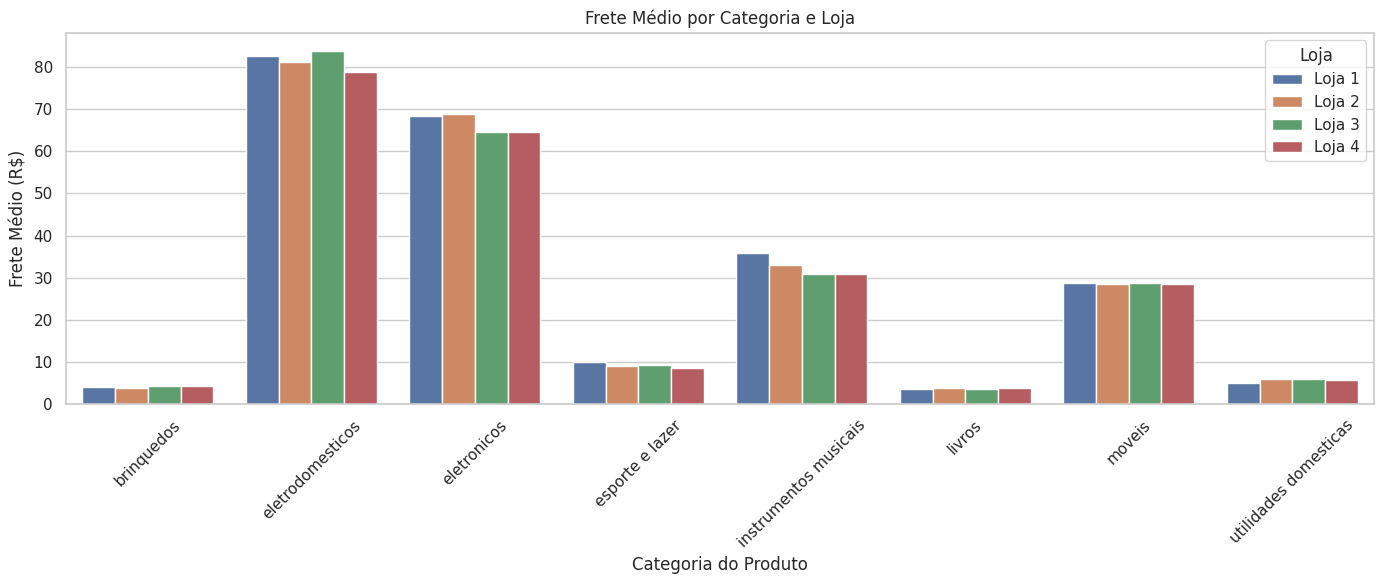

In [28]:
plt.figure(figsize=(14, 6))
sns.barplot(
    data=df_frete_por_categoria,
    x='Categoria do Produto',
    y='Frete_Medio',
    hue='Loja'
)

plt.title('Frete Médio por Categoria e Loja')
plt.xlabel('Categoria do Produto')
plt.ylabel('Frete Médio (R$)')
plt.xticks(rotation=45)
plt.legend(title='Loja')
plt.tight_layout()
plt.show()


E por fim plotei um gráfico de dispersão para verificar a correlação de fretes entre as lojas, comparando valor médio de frete e valor de venda dos produtos

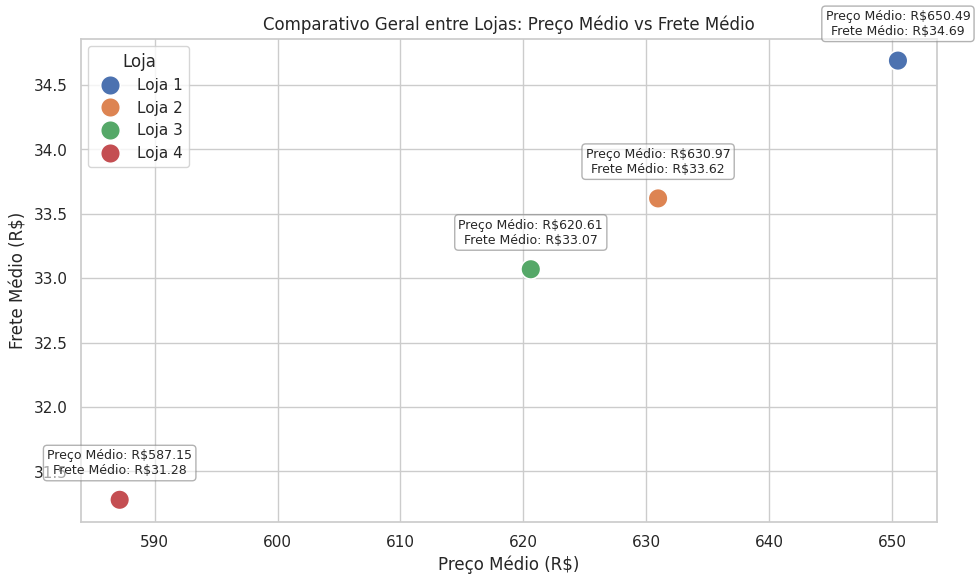

In [29]:
nomes_lojas = ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4']
dados_lojas = []

# Calcula média geral de preço e frete por loja
for idx, loja in enumerate(lojas):
    preco_medio = loja['Preço'].mean()
    frete_medio = loja['Frete'].mean()

    dados_lojas.append({
        'Loja': nomes_lojas[idx],
        'Preco_Medio': round(preco_medio, 2),
        'Frete_Medio': round(frete_medio, 2)
    })

# Cria DataFrame para o gráfico
df_resumo = pd.DataFrame(dados_lojas)

# Gráfico de dispersão
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_resumo, x='Preco_Medio', y='Frete_Medio', hue='Loja', s=200)

# Adiciona os valores como rótulos nos pontos
for i in range(len(df_resumo)):
    preco = df_resumo['Preco_Medio'][i]
    frete = df_resumo['Frete_Medio'][i]

    plt.text(
        x=preco,
        y=frete + 0.2,  # deslocamento para não sobrepor o ponto
        s=f"Preço Médio: R${preco:.2f}\nFrete Médio: R${frete:.2f}",
        ha='center',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.6)
    )

# Títulos e eixos
plt.title('Comparativo Geral entre Lojas: Preço Médio vs Frete Médio')
plt.xlabel('Preço Médio (R$)')
plt.ylabel('Frete Médio (R$)')
plt.grid(True)
plt.tight_layout()
plt.show()

# 6. 🌎 Mapa de Calor de Vendas
Para finalizar, levantei a quantidade de vendas de acordo com a latitude e longitude. Com isso pude determinar os locais exatos das vendas e suas respectivas quantidades.

Organizei as informações em uma tabela para melhor visualização e separei elas para cada loja.

In [30]:
# Agrupa por lat/lon para cada loja individualmente
vendas_loja1 = loja1.groupby(['lat', 'lon']).size().reset_index(name='Vendas Loja 1')
vendas_loja2 = loja2.groupby(['lat', 'lon']).size().reset_index(name='Vendas Loja 2')
vendas_loja3 = loja3.groupby(['lat', 'lon']).size().reset_index(name='Vendas Loja 3')
vendas_loja4 = loja4.groupby(['lat', 'lon']).size().reset_index(name='Vendas Loja 4')

# Converte as tabelas para HTML com estilos de exibição lado a lado
html = f"""
<div style="display: flex; justify-content: space-evenly; gap: 20px;">
    <div style="flex: 1;">
        <h4>Loja 1</h4>
        {vendas_loja1.head().to_html(index=False)}
    </div>
    <div style="flex: 1;">
        <h4>Loja 2</h4>
        {vendas_loja2.head().to_html(index=False)}
    </div>
    <div style="flex: 1;">
        <h4>Loja 3</h4>
        {vendas_loja3.head().to_html(index=False)}
    </div>
    <div style="flex: 1;">
        <h4>Loja 4</h4>
        {vendas_loja4.head().to_html(index=False)}
    </div>
</div>
"""

# Exibe as tabelas
display(HTML(html))

print("\n\n")
# Faz merge incremental dos DataFrames para juntar todas as lojas por coordenada
vendas_agrupadas = vendas_loja1.merge(vendas_loja2, on=['lat', 'lon'], how='outer')
vendas_agrupadas = vendas_agrupadas.merge(vendas_loja3, on=['lat', 'lon'], how='outer')
vendas_agrupadas = vendas_agrupadas.merge(vendas_loja4, on=['lat', 'lon'], how='outer')

# Substitui NaNs por 0 (caso uma loja não tenha vendas naquela coordenada)
vendas_agrupadas.fillna(0, inplace=True)

# Converte para inteiros
for col in ['Vendas Loja 1', 'Vendas Loja 2', 'Vendas Loja 3', 'Vendas Loja 4']:
    vendas_agrupadas[col] = vendas_agrupadas[col].astype(int)

# Cria uma coluna de total de vendas em todas as lojas para cada ponto
vendas_agrupadas['Vendas Totais'] = vendas_agrupadas[['Vendas Loja 1', 'Vendas Loja 2', 'Vendas Loja 3', 'Vendas Loja 4']].sum(axis=1)

# Exibe o resultado
print(vendas_agrupadas.head())

lat,lon,Vendas Loja 1
-30.17,-53.50,155
-27.45,-50.95,95
-24.89,-51.55,128
-22.25,-42.66,298
-22.19,-48.79,984
lat,lon,Vendas Loja 2
-30.17,-53.50,124
-27.45,-50.95,94
-24.89,-51.55,98
-22.25,-42.66,311





     lat    lon  Vendas Loja 1  Vendas Loja 2  Vendas Loja 3  Vendas Loja 4  Vendas Totais
0 -30.17 -53.50            155            124            128            127            534
1 -27.45 -50.95             95             94             77             80            346
2 -24.89 -51.55            128             98            120            127            473
3 -22.25 -42.66            298            311            295            308           1212
4 -22.19 -48.79            984            985            983            991           3943


Com as informações acima, criei um mapa de calor utilizando a biblioteca folium. Para uma visualização mais acertiva, crieiuma função para obter a região de onde as vendas foram feitas, utilizei respectivamente os Estados e as Coordenadas de cada venda, e com isso pude determinar a localização no mapa e exibí-las em um icone para cada região.

In [31]:
# Função auxiliar (mock) para nomear regiões com base em coordenadas
def obter_regiao_geografica(lat, lon):
    estados = {
        'AC': 'Norte', 'AL': 'Nordeste', 'AM': 'Norte', 'AP': 'Norte', 'BA': 'Nordeste', 'CE': 'Nordeste',
        'DF': 'Centro-Oeste', 'ES': 'Sudeste', 'GO': 'Centro-Oeste', 'MA': 'Nordeste', 'MT': 'Centro-Oeste',
        'MS': 'Centro-Oeste', 'MG': 'Sudeste', 'PA': 'Norte', 'PB': 'Nordeste', 'PR': 'Sul', 'PE': 'Nordeste',
        'PI': 'Nordeste', 'RJ': 'Sudeste', 'RN': 'Nordeste', 'RO': 'Norte', 'RS': 'Sul', 'RR': 'Norte',
        'SC': 'Sul', 'SE': 'Nordeste', 'SP': 'Sudeste', 'TO': 'Norte'
    }

    coordenadas_estados = {
        'AC': (-8.77, -70.55), 'AL': (-9.71, -35.73), 'AM': (-3.07, -61.66), 'AP': (1.41, -51.77),
        'BA': (-12.96, -38.51), 'CE': (-3.71, -38.54), 'DF': (-15.83, -47.86), 'ES': (-19.19, -40.34),
        'GO': (-16.64, -49.31), 'MA': (-2.55, -44.30), 'MT': (-12.64, -55.42), 'MS': (-20.51, -54.54),
        'MG': (-18.10, -44.38), 'PA': (-5.53, -52.29), 'PB': (-7.06, -35.55), 'PR': (-24.89, -51.55),
        'PE': (-8.28, -35.07), 'PI': (-8.28, -43.68), 'RJ': (-22.84, -43.15), 'RN': (-5.22, -36.52),
        'RO': (-11.22, -62.80), 'RS': (-30.01, -51.22), 'RR': (1.89, -61.22), 'SC': (-27.33, -49.44),
        'SE': (-10.90, -37.07), 'SP': (-23.55, -46.64), 'TO': (-10.25, -48.25)
    }

    menor_distancia = float('inf')
    uf_mais_proxima = None
    for uf, coord_ref in coordenadas_estados.items():
        distancia = ((lat - coord_ref[0])**2 + (lon - coord_ref[1])**2) ** 0.5
        if distancia < menor_distancia:
            menor_distancia = distancia
            uf_mais_proxima = uf

    return estados.get(uf_mais_proxima, "Outras")

# Dicionário com os DataFrames das lojas
lojas_dfs = {
    "Loja 1": loja1,
    "Loja 2": loja2,
    "Loja 3": loja3,
    "Loja 4": loja4,
}

# Inicializa o mapa centralizado no Brasil
mapa = folium.Map(location=[-14.2, -51.9], zoom_start=4, control_scale=True)

# Variáveis para dados do mapa
heat_data = []
localizacao_vendas = defaultdict(lambda: defaultdict(int))
regioes_totais = defaultdict(int)

# Agrupar dados de localização e vendas
for nome_loja, df in lojas_dfs.items():
    for _, row in df.dropna(subset=['lat', 'lon']).iterrows():
        coord = (round(row['lat'], 1), round(row['lon'], 1))
        heat_data.append([row['lat'], row['lon']])
        localizacao_vendas[coord][nome_loja] += 1

# Adiciona o HeatMap
HeatMap(heat_data).add_to(mapa)

# Adiciona marcadores nas regiões com popup
for coord, lojas_info in localizacao_vendas.items():
    nome_regiao = obter_regiao_geografica(coord[0], coord[1])
    total_popup = f"<b>Região: {nome_regiao}</b><br>"
    for loja, qtd in lojas_info.items():
        total_popup += f"{loja}: {qtd} vendas<br>"
        regioes_totais[nome_regiao] += qtd

    folium.Marker(
        location=coord,
        popup=folium.Popup(total_popup, max_width=300),
        icon=folium.Icon(color='red', icon='shopping-cart', prefix='fa'),
    ).add_to(mapa)

# Exibe o mapa no notebook
display(mapa)

# 📊 Relatório Final sobre a Análise
---

## 🧾 Análise de Faturamento

As quatro lojas apresentam um desempenho semelhante em quantidade de vendas (em torno de 2.359 por loja), mas se diferenciam pelo faturamento total e ticket médio:

| Loja  | Faturamento (R$)      | Vendas Totais | Ticket Médio |
|-------|-------------------|----------------|----------------|
| Loja 1 | 1.534.509,12   | &nbsp;&nbsp;&nbsp;2.359          | 650,58      |
| Loja 2 | 1.488.459,06   | &nbsp;&nbsp;&nbsp;2.359          | 631,01      |
| Loja 3 | 1.464.025,03   | &nbsp;&nbsp;&nbsp;2.359          | 620,63      |
| Loja 4 | 1.384.497,58   | &nbsp;&nbsp;&nbsp;2.358          | 587,09      |

🔍 **Insight:** A Loja 1 tem o maior ticket médio e o maior faturamento, indicando melhor rentabilidade por venda. A Loja 4 apresenta o pior desempenho em ambos.

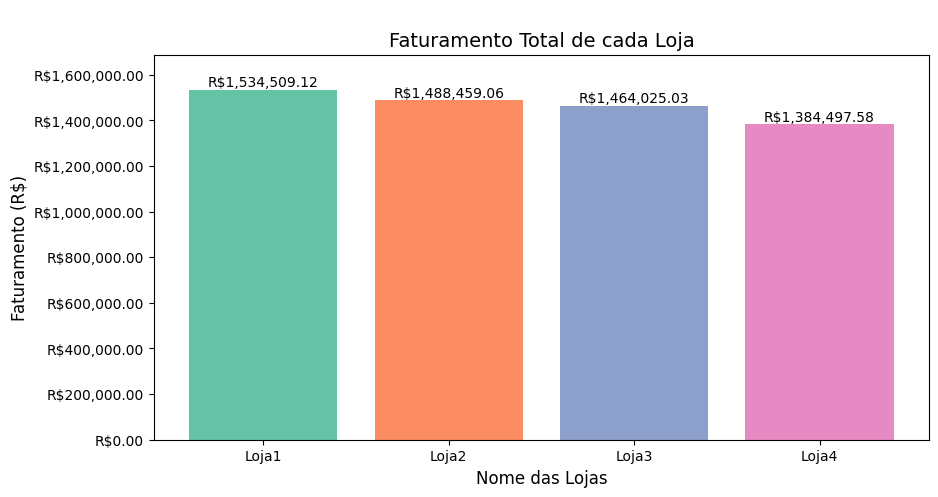

---

## 📦 Vendas por Categoria

Analisando o valor total de vendas por categoria:

- **Eletrônicos** e **Eletrodomésticos** são as categorias mais lucrativas em todas as lojas.
- **Livros** e **Brinquedos** têm menor valor agregado, mas mantêm boa rotatividade.
- A **Loja 1** lidera nas categorias mais valiosas (eletrônicos, eletrodomésticos).
- A **Loja 4** tem menor desempenho geral, mesmo nas categorias fortes.

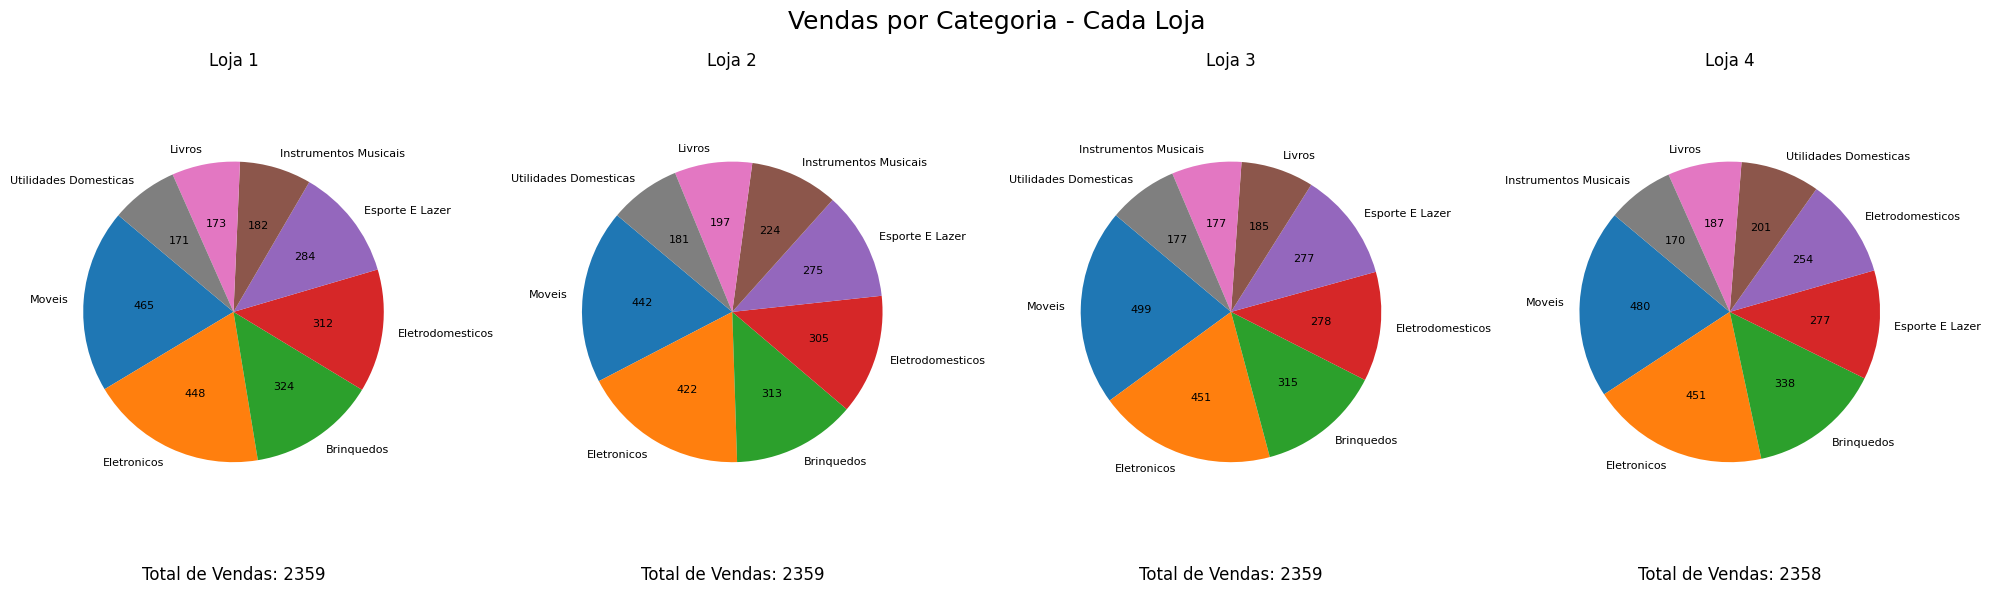


---

## ⭐ Média de Avaliação das Lojas

| Loja  | Nota Média |
|-------|-------------|
| Loja 1 | ⭐ 3.98       |
| Loja 2 | ⭐ 4.04       |
| Loja 3 | ⭐ 4.05       |
| Loja 4 | ⭐ 4.00      |

🔍 **Insight:** A Loja 3 é a melhor avaliada pelos clientes. A Loja 1, embora tenha o maior faturamento, é a que possui a pior nota média de avaliação, o que pode indicar problemas de atendimento ou logística.

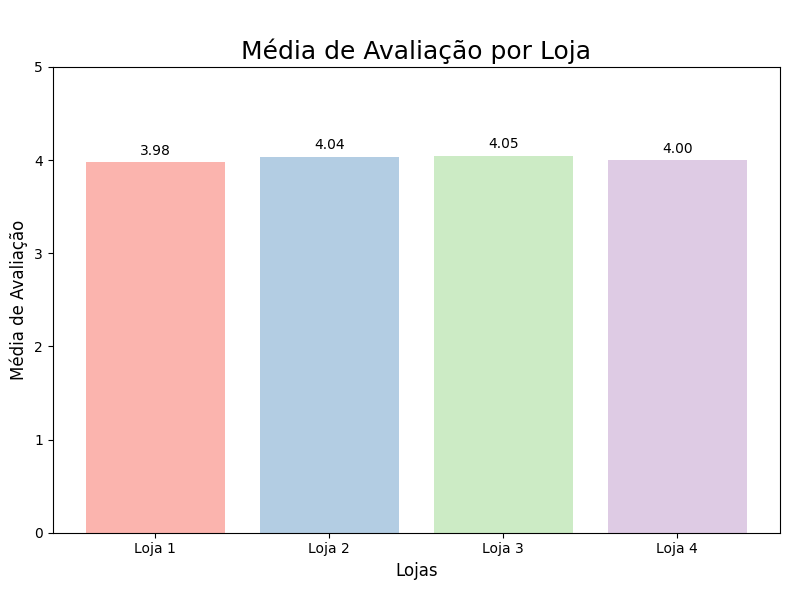

---

## 🛒 Produtos Mais e Menos Vendidos

### Produtos Mais Vendidos
- Eletrônicos, móveis e eletrodomésticos estão entre os mais vendidos em todas as lojas.
- A **Loja 2** mostra maior equilíbrio entre categorias.

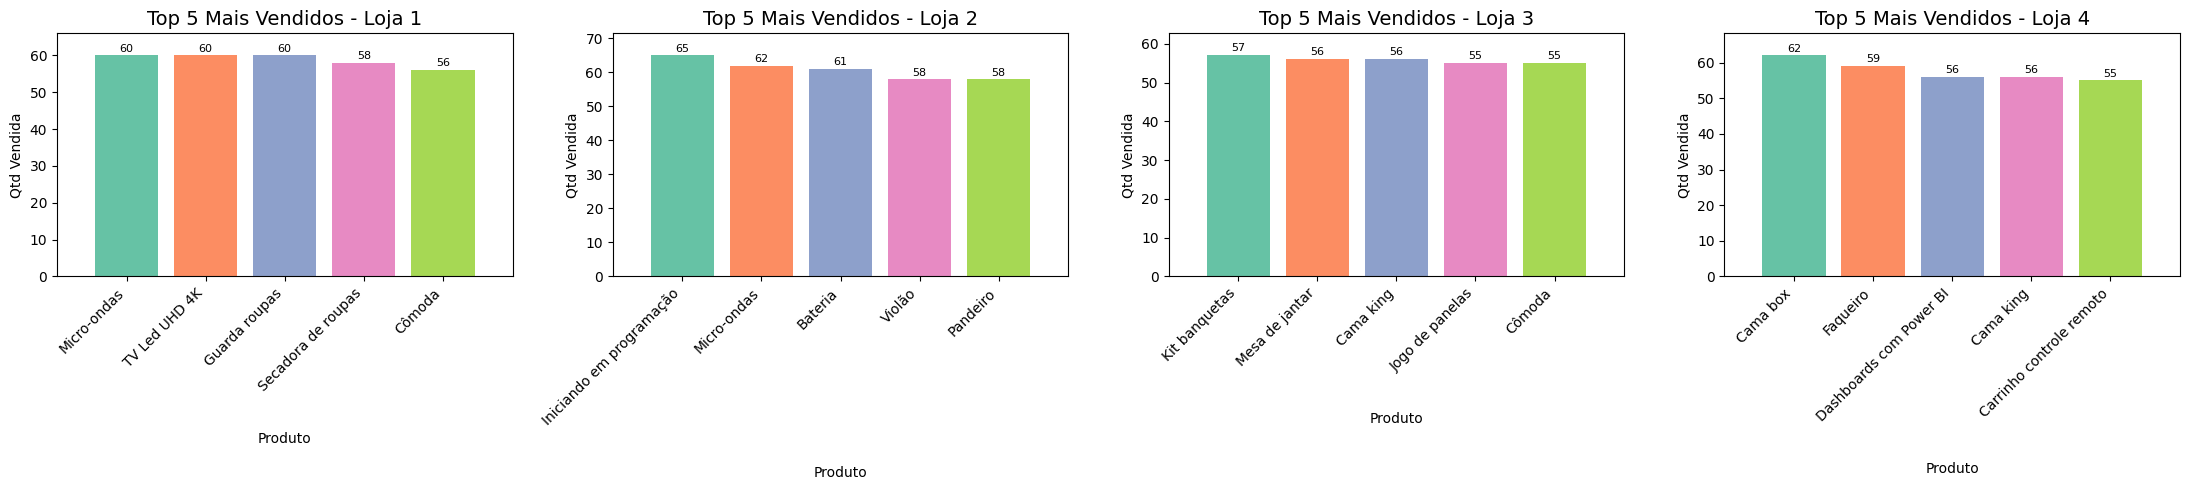

### Produtos Menos Vendidos
- Instrumentos musicais e livros aparecem frequentemente entre os menos vendidos.
- A **Loja 4** possui maior número de categorias com baixo giro, o que afeta seu desempenho geral.

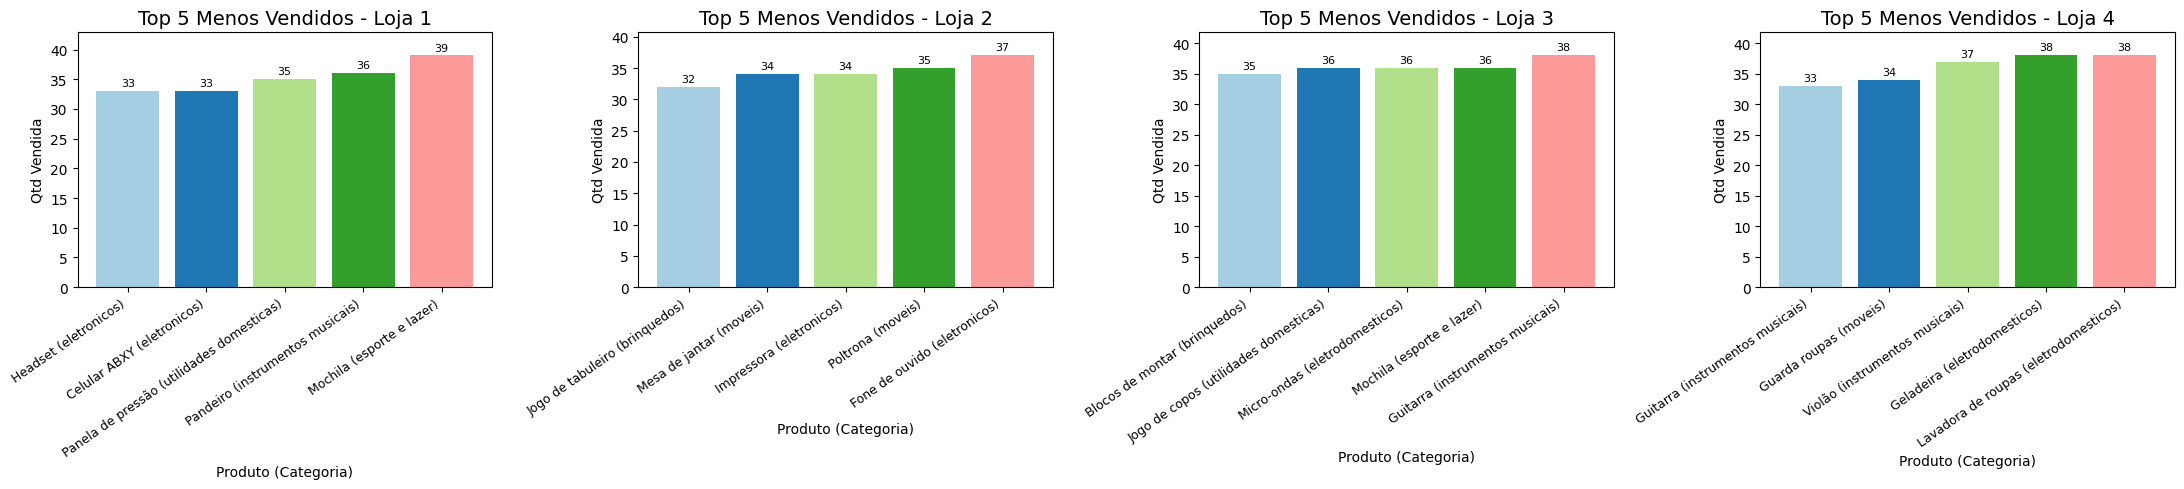

---

## 🚚 Frete Médio por Loja


Comparativo de Frete entre lojas:

| Loja |	Frete Médio |	Preço Médio |	% Frete sobre Preço |	Total de Fretes |
|--------|--------|--------|-------|-----------|
|	Loja 1 |	34.69 |	650.49 |	5.33 |	81837.97 |
|	Loja 2 |	33.62 |	630.97 |	5.33 |	79314.16 |
|	Loja 3 |	33.07 |	620.61 |	5.33 |	78022.66 |
|	Loja 4 |	31.28 |	587.15 |	5.33 |	73755.88 |

&nbsp;  

Comparativo de Frete por Categoria entre lojas:

| Categoria do Produto |	Qtd de Vendas |	Frete_Medio	| Preco_Medio_Produto |	Frete_Total |	% Frete sobre Preço |
|------------|-----|-----|-------|-----|-----------|
|	Brinquedos |	1290 |	4.16 |	76.08 |	5361.50 |	5.46 |
|	Eletrodomésticos |	1149 |	81.69	| 1537.28 |	93861.63 |	5.31 |
|	Eletrônicos |	1772 |	66.56 |	1249.49 |	117948.36 |	5.33 |
|	Esporte e lazer |	1113 |	9.22 |	171.28 |	10256.55 |	5.38 |
|	Instrumentos musicais |	753 |	32.76 |	617.57 |	24671.81 |	5.31 |
|	Livros |	742 |	3.70 |	67.74 |	2746.69 |	5.46 |
|	Móveis |	1886 |	28.60 |	535.64 |	53935.77 |	5.34 |
|	Utilidades domésticas |	730 |	5.68 |	105.17 |	4148.34 |	5.40 |

O frete médio por categorias é semelhante entre as lojas, girando em torno de 5.3% a 5.46% do preço médio dos produtos.

🔍 **Insight:** A **Loja 4** apresenta o menor custo relativo de frete, apesar da baixa lucratividade em relação as demais lojas.

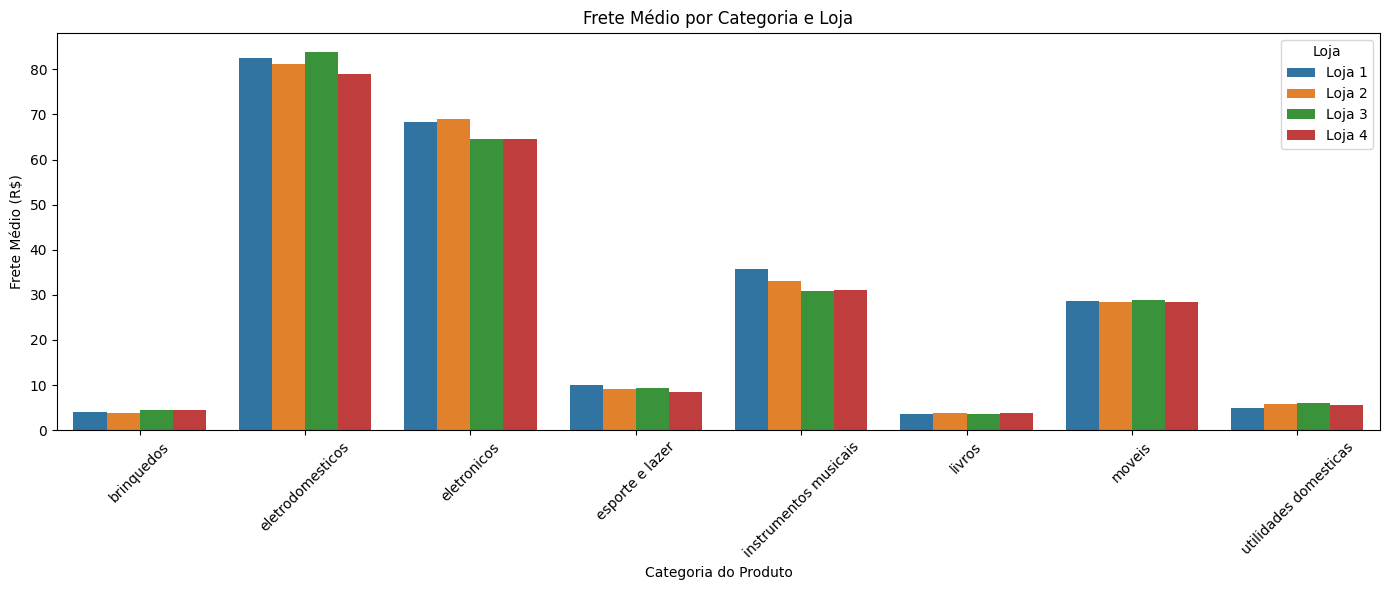

---

## ✅ Conclusão

Após analisar todos os aspectos – faturamento, avaliação dos clientes, desempenho por categoria e frete – as lojas se classificam da seguinte forma:

**Ranking Geral de Desempenho:**

1. 🥇 **Loja 1** – Maior faturamento e ticket médio, apesar da menor avaliação.
2. 🥈 **Loja 2** – Boa avaliação e equilíbrio entre categorias.
3. 🥉 **Loja 3** – Média em todos os quesitos.
4. ❌ **Loja 4** – Menor faturamento, menor ticket médio, segunda pior nas avaliações.

👉 **Recomendação final:** O Sr. João deve considerar a **venda da Loja 4**, por apresentar desempenho inferior de forma consistente. Com a venda, ele pode recuperar capital para investir em novas oportunidades ou fortalecer as operações das lojas mais rentáveis.